In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import time

from mlxtend.frequent_patterns import (
    fpgrowth,
    apriori,
    association_rules
)

sns.set_style("ticks")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
transactions = pd.read_excel(
    "Online Retail.xlsx"
)

transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# Dataset Introduction

The Online Retail dataset contains customer invoices collected from an online retailer. Every row corresponds to one purchased product. Since multiple products may belong to the same invoice, the dataset is appropriate for market basket analysis and association rule mining.

In [4]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
transactions.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


# Initial Exploration

Before preparing the transaction basket, the dataset was examined to understand the available variables, missing values, and transaction characteristics. This helps determine which records should be removed during preprocessing.

In [6]:
missing = (
    transactions
    .isnull()
    .sum()
    .reset_index()
)

missing.columns = [
    "Column",
    "Missing Values"
]

missing

,Column,Missing Values
0,InvoiceNo,0
1,StockCode,0
2,Description,1454
3,Quantity,0
4,InvoiceDate,0
5,UnitPrice,0
6,CustomerID,135080
7,Country,0


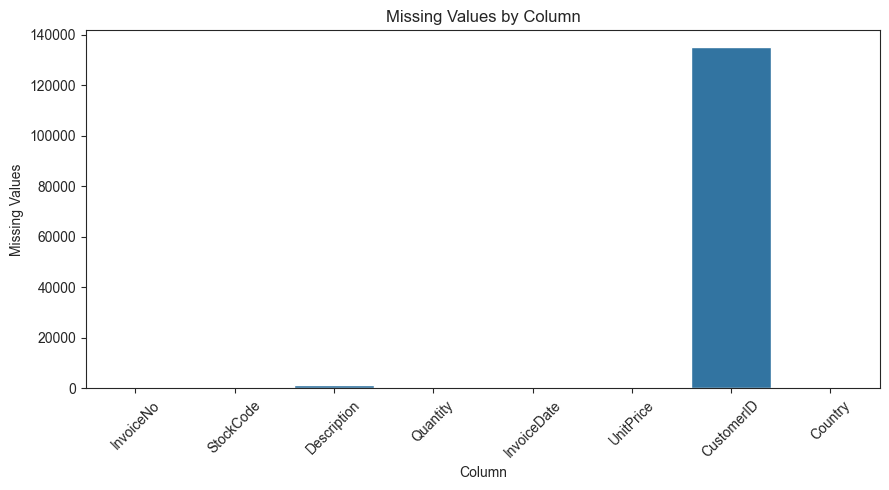

In [7]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=missing,
    x="Column",
    y="Missing Values"
)

plt.xticks(rotation=45)

plt.title("Missing Values by Column")

plt.tight_layout()

plt.show()

# Missing Data Analysis

Most variables are complete except for the customer identifier and a few product descriptions. Missing product descriptions cannot be used in association rule mining and will therefore be removed during data cleaning.

In [8]:
retail = transactions.copy()

retail = retail.dropna(
    subset=["Description"]
)

retail = retail[
    retail["Quantity"] > 0
]

retail = retail[
    retail["UnitPrice"] > 0
]

retail = retail[
    ~retail["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
]

retail["Description"] = (
    retail["Description"]
    .str.upper()
    .str.strip()
)

retail.shape

(530104, 8)

# Data Cleaning Summary

Records associated with cancelled invoices, returned products, missing descriptions, and invalid prices were removed. Product descriptions were standardized to uppercase to prevent duplicate item names caused by inconsistent formatting.

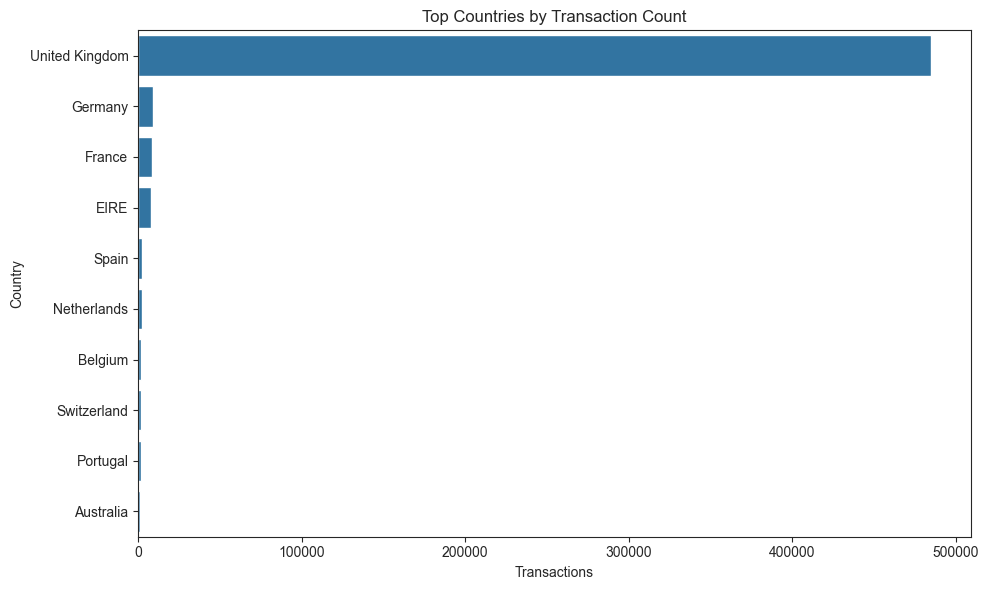

In [9]:
country_counts = (
    retail["Country"]
    .value_counts()
    .head(10)
    .reset_index()
)

country_counts.columns = [
    "Country",
    "Transactions"
]

plt.figure(figsize=(10,6))

sns.barplot(
    data=country_counts,
    x="Transactions",
    y="Country"
)

plt.title("Top Countries by Transaction Count")

plt.tight_layout()

plt.show()

# Country Distribution

Most retail transactions originate from the United Kingdom. To reduce computational complexity and maintain consistency, only United Kingdom transactions will be used in the association mining process.

In [10]:
uk_sales = retail[
    retail["Country"] == "United Kingdom"
]

print("Rows:", len(uk_sales))
print("Invoices:", uk_sales["InvoiceNo"].nunique())
print("Products:", uk_sales["Description"].nunique())

Rows: 485123
Invoices: 18019
Products: 3996


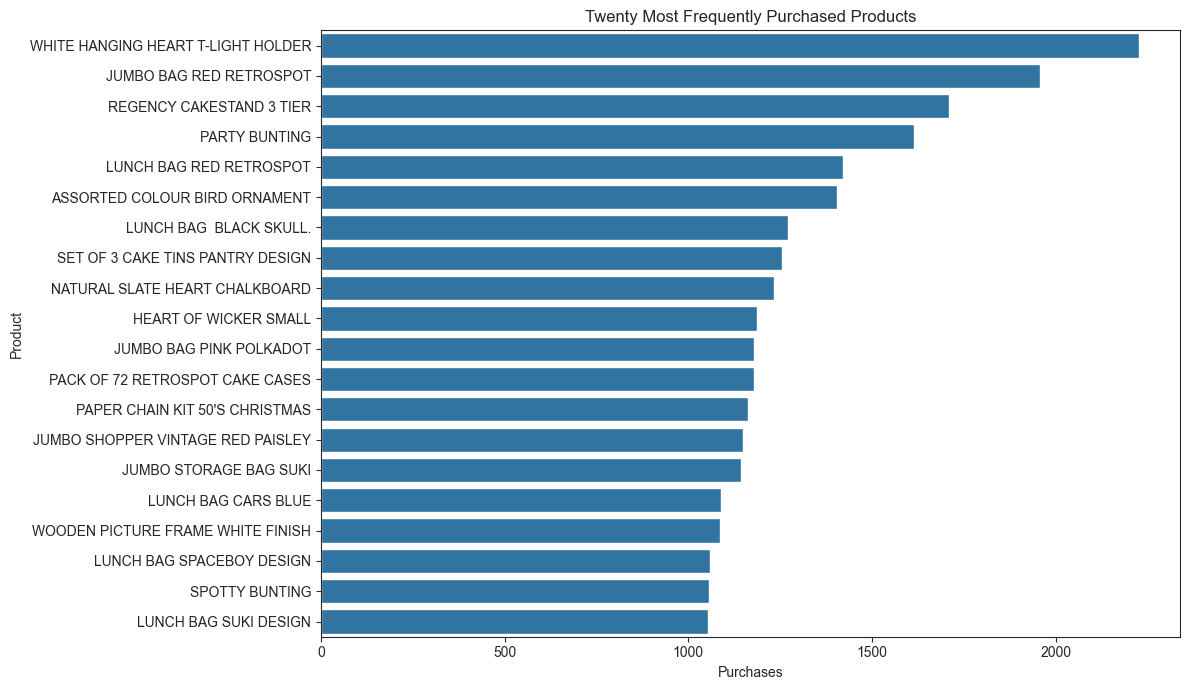

In [11]:
popular_products = (
    uk_sales["Description"]
    .value_counts()
    .head(20)
    .reset_index()
)

popular_products.columns = [
    "Product",
    "Purchases"
]

plt.figure(figsize=(12,7))

sns.barplot(
    data=popular_products,
    x="Purchases",
    y="Product"
)

plt.title("Twenty Most Frequently Purchased Products")

plt.tight_layout()

plt.show()

# Frequently Purchased Products

Frequently purchased products generally produce higher support values during association mining. These products are more likely to appear within meaningful product combinations and therefore provide a good starting point for market basket analysis.

In [12]:
selected_items = (
    uk_sales["Description"]
    .value_counts()
    .head(40)
    .index
)

basket_source = uk_sales[
    uk_sales["Description"]
    .isin(selected_items)
]

basket_source.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom
21,536368,22960,JAM MAKING SET WITH JARS,6,2010-12-01 08:34:00,4.25,13047.0,United Kingdom
46,536371,22086,PAPER CHAIN KIT 50'S CHRISTMAS,80,2010-12-01 09:00:00,2.55,13748.0,United Kingdom
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:02:00,2.55,17850.0,United Kingdom


In [13]:
basket = (
    basket_source
    .groupby(
        ["InvoiceNo","Description"]
    )["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = basket.gt(0)

basket.head()

Description,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,ASSORTED COLOUR BIRD ORNAMENT,GARDENERS KNEELING PAD KEEP CALM,GREEN REGENCY TEACUP AND SAUCER,HEART OF WICKER LARGE,HEART OF WICKER SMALL,JAM MAKING SET PRINTED,JAM MAKING SET WITH JARS,JUMBO BAG BAROQUE BLACK WHITE,...,REX CASH+CARRY JUMBO SHOPPER,ROSES REGENCY TEACUP AND SAUCER,SET OF 3 CAKE TINS PANTRY DESIGN,SET OF 4 PANTRY JELLY MOULDS,SPOTTY BUNTING,VICTORIAN GLASS HANGING T-LIGHT,VINTAGE SNAP CARDS,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
536367,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
536371,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536373,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,True


# Boolean Transaction Matrix

Each invoice is represented by one row, while each product forms a separate column. A value of **True** indicates that the product appears in the transaction, whereas **False** indicates that it does not. This Boolean matrix serves as the input for both FP-Growth and Apriori algorithms.

# FP-Growth Pattern Discovery

FP-Growth is applied first in this notebook to identify products that frequently occur together. Unlike candidate-based methods, FP-Growth stores transaction patterns in a compressed tree structure and extracts frequent itemsets without repeatedly generating candidate combinations.

A minimum support value of 0.02 is used. This means an itemset must appear in at least 2% of the selected invoices to be considered frequent.

In [14]:
minimum_support = 0.02

fp_start_time = time.perf_counter()

fp_itemsets = fpgrowth(
    basket,
    min_support=minimum_support,
    use_colnames=True
)

fp_runtime = time.perf_counter() - fp_start_time

print(f"Number of FP-Growth itemsets: {len(fp_itemsets)}")
print(f"FP-Growth execution time: {fp_runtime:.6f} seconds")

Number of FP-Growth itemsets: 231
FP-Growth execution time: 1.402362 seconds


# FP-Growth Execution Summary

The output reports the total number of itemsets satisfying the minimum support requirement and the time required to complete the mining process.

Execution time may vary according to the computer, Python environment, number of invoices, number of selected products, and support threshold.

In [15]:
fp_itemsets["itemset_size"] = fp_itemsets["itemsets"].apply(len)

fp_ranked = (
    fp_itemsets
    .sort_values(
        by=["itemset_size", "support"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

fp_ranked.head(15)

,support,itemsets,itemset_size
0,0.022137,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG P...",4
1,0.033959,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG P...",3
2,0.032199,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG R...",3
3,0.030689,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO BAG ...",3
4,0.030102,"frozenset({ROSES REGENCY TEACUP AND SAUCER, GR...",3
5,0.029012,"frozenset({LUNCH BAG BLACK SKULL., LUNCH BAG ...",3
6,0.026664,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO BAG ...",3
7,0.026413,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG R...",3
8,0.026161,"frozenset({LUNCH BAG SUKI DESIGN, LUNCH BAG B...",3
9,0.025826,"frozenset({LUNCH BAG CARS BLUE, LUNCH BAG BLA...",3


# Frequent Itemset Structure

The `itemset_size` column shows how many products are included in each discovered combination.

- An itemset size of 1 represents an individual product.
- An itemset size of 2 represents a product pair.
- Larger values represent combinations containing three or more products.

Sorting the results by itemset size and support makes it easier to identify both complex combinations and commonly occurring patterns.

In [16]:
fp_size_summary = (
    fp_itemsets["itemset_size"]
    .value_counts()
    .sort_index()
    .rename_axis("Itemset Size")
    .reset_index(name="Number of Itemsets")
)

fp_size_summary

,Itemset Size,Number of Itemsets
0,1,40
1,2,149
2,3,41
3,4,1


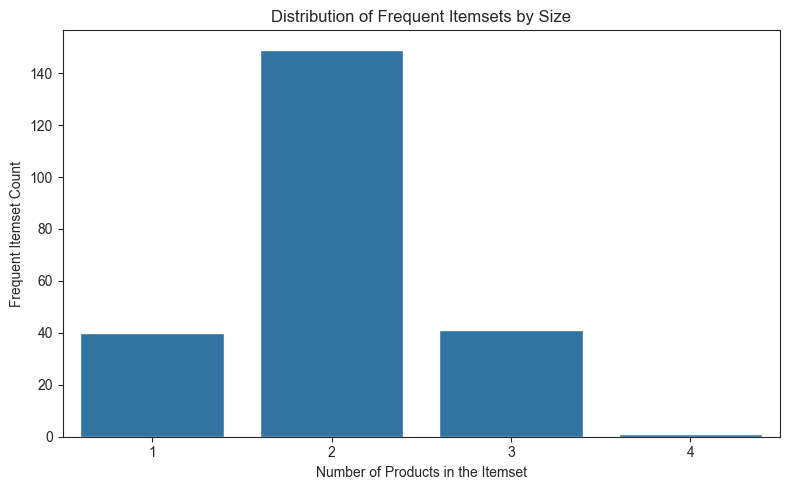

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=fp_size_summary,
    x="Itemset Size",
    y="Number of Itemsets"
)

plt.title("Distribution of Frequent Itemsets by Size")
plt.xlabel("Number of Products in the Itemset")
plt.ylabel("Frequent Itemset Count")

plt.tight_layout()
plt.show()

# Itemset Size Interpretation

The chart compares the number of frequent single products, product pairs, and larger product combinations.

Single-item patterns are normally more common because individual products have a greater chance of meeting the support threshold. Larger combinations are less frequent because all products in the combination must appear within the same invoices.

In [18]:
fp_multi_itemsets = fp_itemsets[
    fp_itemsets["itemset_size"] >= 2
].copy()

fp_multi_itemsets["itemset_label"] = (
    fp_multi_itemsets["itemsets"]
    .apply(lambda values: " + ".join(sorted(values)))
)

top_fp_combinations = (
    fp_multi_itemsets
    .sort_values("support", ascending=False)
    .head(12)
)

top_fp_combinations[
    ["itemset_label", "support", "itemset_size"]
]

,itemset_label,support,itemset_size
58,JUMBO BAG PINK POLKADOT + JUMBO BAG RED RETROSPOT,0.065823,2
163,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENC...,0.058695,2
63,JUMBO BAG RED RETROSPOT + JUMBO STORAGE BAG SUKI,0.058528,2
92,JUMBO BAG RED RETROSPOT + JUMBO SHOPPER VINTAG...,0.055090,2
148,LUNCH BAG BLACK SKULL. + LUNCH BAG RED RETROSPOT,0.050897,2
80,JUMBO BAG BAROQUE BLACK WHITE + JUMBO BAG RED...,0.047795,2
97,ALARM CLOCK BAKELIKE GREEN + ALARM CLOCK BAKEL...,0.047208,2
115,LUNCH BAG PINK POLKADOT + LUNCH BAG RED RETROSPOT,0.046453,2
54,JUMBO BAG RED RETROSPOT + LUNCH BAG RED RETROSPOT,0.044525,2
51,WOODEN FRAME ANTIQUE WHITE + WOODEN PICTURE FR...,0.044273,2


# Multi-Product Combinations

Only itemsets containing two or more products are included in this table. These patterns are more useful for market basket analysis because they show which products occur together rather than simply identifying popular individual items.

The support value represents the proportion of selected invoices containing the complete product combination.

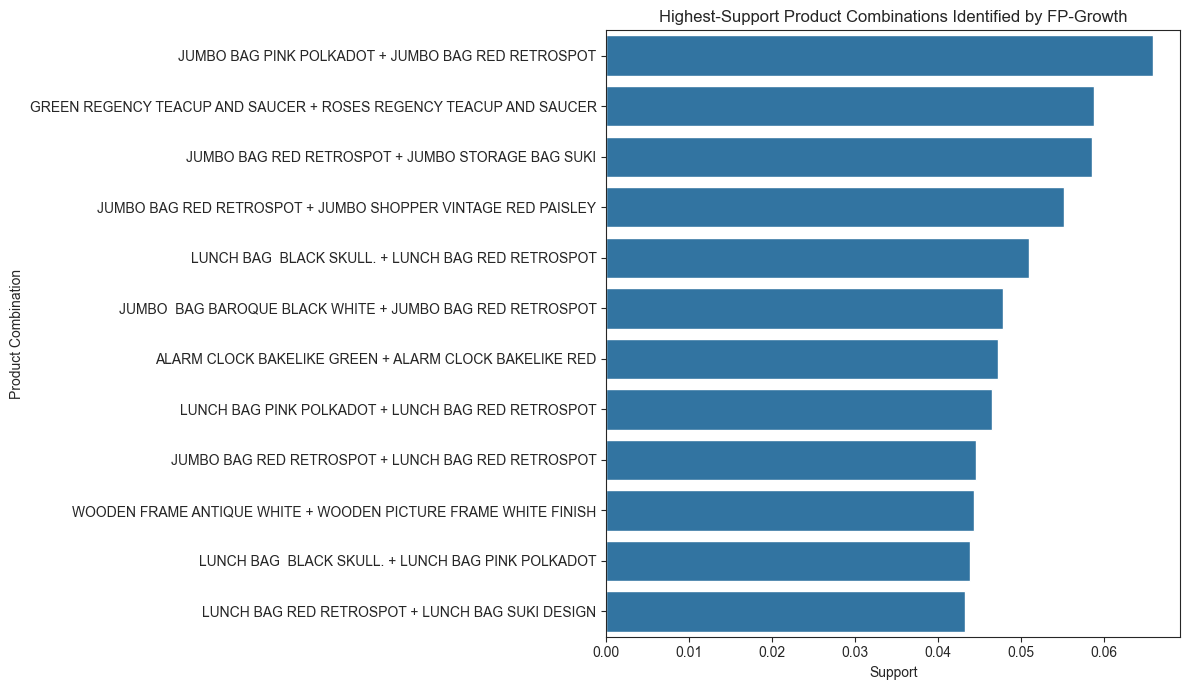

In [19]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_fp_combinations,
    x="support",
    y="itemset_label"
)

plt.title("Highest-Support Product Combinations Identified by FP-Growth")
plt.xlabel("Support")
plt.ylabel("Product Combination")

plt.tight_layout()
plt.show()

# Support-Based Comparison

The horizontal bar chart ranks multi-product itemsets according to support. Longer bars represent product combinations that occur in a larger percentage of invoices.

These combinations may be useful for product bundling, cross-selling, coordinated promotions, and recommendation strategies. However, support alone does not establish whether the relationship is stronger than random purchasing behavior. Confidence and lift will therefore be evaluated next.

In [20]:
fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.50
)

fp_rules = fp_rules[
    fp_rules["lift"] > 1
].copy()

fp_rules["antecedent_text"] = (
    fp_rules["antecedents"]
    .apply(lambda values: ", ".join(sorted(values)))
)

fp_rules["consequent_text"] = (
    fp_rules["consequents"]
    .apply(lambda values: ", ".join(sorted(values)))
)

print(f"Number of FP-Growth association rules: {len(fp_rules)}")

Number of FP-Growth association rules: 126


# Association Rule Evaluation

Association rules are created using a minimum confidence threshold of 0.50. Therefore, the consequent must occur in at least 50% of the transactions containing the antecedent.

Rules with lift values greater than 1 are retained because they indicate positive relationships. A lift above 1 suggests that the antecedent and consequent occur together more often than expected under independent purchasing behavior.

In [21]:
fp_rule_view = (
    fp_rules[
        [
            "antecedent_text",
            "consequent_text",
            "support",
            "confidence",
            "lift"
        ]
    ]
    .sort_values(
        by=["lift", "confidence"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

fp_rule_view.head(15)

,antecedent_text,consequent_text,support,confidence,lift
0,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",GREEN REGENCY TEACUP AND SAUCER,0.030102,0.790749,10.118532
1,"JUMBO BAG PINK POLKADOT, JUMBO SHOPPER VINTAGE...","JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI",0.022137,0.581498,9.935448
2,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.030102,0.790749,9.864510
3,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI","JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",0.022137,0.522772,9.489471
4,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.058695,0.732218,9.369557
5,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.058695,0.751073,9.369557
6,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.047208,0.642694,8.241688
7,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.047208,0.605376,8.241688
8,"JUMBO SHOPPER VINTAGE RED PAISLEY, JUMBO STORA...","JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",0.022137,0.514620,7.818289
9,"LUNCH BAG BLACK SKULL., LUNCH BAG APPLE DESIGN",LUNCH BAG SUKI DESIGN,0.021801,0.654912,7.649832


# Rule Metrics

The association rules are evaluated using three primary measures:

- **Support** measures how frequently the antecedent and consequent occur together in all invoices.
- **Confidence** measures how frequently the consequent appears when the antecedent is present.
- **Lift** compares the observed relationship with the frequency expected if both sides of the rule were independent.

Rules with strong confidence and lift may reveal useful product relationships even when their overall support is moderate.

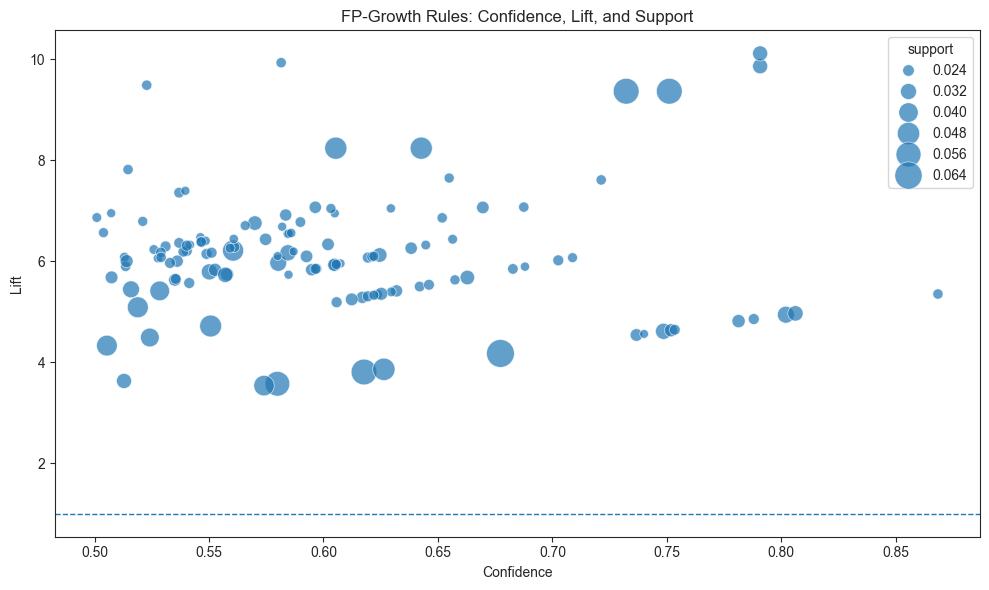

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=fp_rules,
    x="confidence",
    y="lift",
    size="support",
    sizes=(40, 400),
    alpha=0.7
)

plt.axhline(
    y=1,
    linestyle="--",
    linewidth=1
)

plt.title("FP-Growth Rules: Confidence, Lift, and Support")
plt.xlabel("Confidence")
plt.ylabel("Lift")

plt.tight_layout()
plt.show()

# Relationship Between Confidence, Lift, and Support

Each point represents one association rule. Its horizontal position represents confidence, its vertical position represents lift, and its size represents support.

Rules located toward the upper-right area combine high confidence with high lift. Larger points indicate rules that also occur in a greater proportion of invoices. This visualization helps distinguish commonly occurring rules from rules that demonstrate especially strong product dependence.

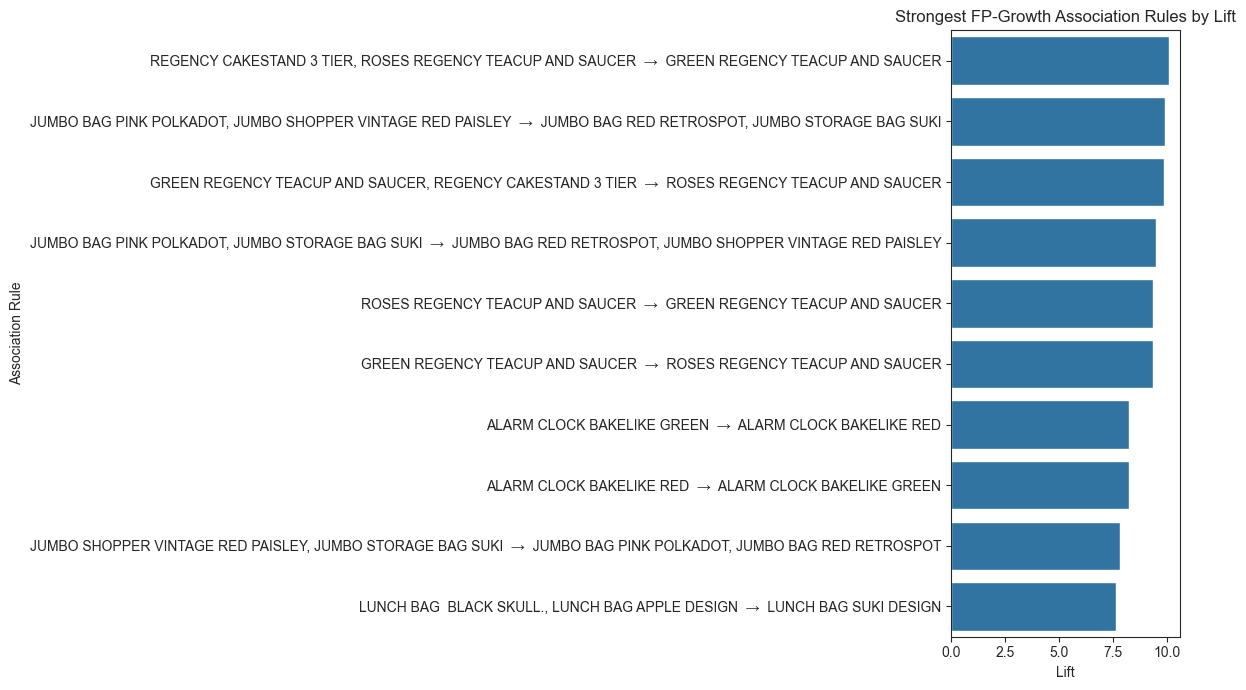

In [23]:
top_lift_rules = (
    fp_rule_view
    .head(10)
    .copy()
)

top_lift_rules["rule_label"] = (
    top_lift_rules["antecedent_text"]
    + "  →  "
    + top_lift_rules["consequent_text"]
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_lift_rules,
    x="lift",
    y="rule_label"
)

plt.title("Strongest FP-Growth Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.tight_layout()
plt.show()

# Strongest Positive Associations

The rules shown in the chart have the highest lift values among the retained FP-Growth results. These relationships occur more frequently than expected if the products were purchased independently.

High-lift rules can support targeted recommendations and product bundling. Nevertheless, business decisions should consider support and confidence together with lift so that rare but unusually strong rules are not treated the same as broadly applicable purchasing patterns.

# Apriori Frequent Pattern Mining

After evaluating FP-Growth, the Apriori algorithm is applied using the same transaction basket and support threshold. This allows both algorithms to be compared fairly because they analyze identical transaction data under the same conditions.

In [24]:
apriori_start = time.perf_counter()

apriori_itemsets = apriori(
    basket,
    min_support=minimum_support,
    use_colnames=True
)

apriori_runtime = time.perf_counter() - apriori_start

print(f"Apriori Itemsets: {len(apriori_itemsets)}")
print(f"Execution Time: {apriori_runtime:.6f} seconds")

Apriori Itemsets: 231
Execution Time: 0.249001 seconds


# Apriori Output

The Apriori algorithm identifies frequent product combinations by repeatedly generating candidate itemsets and removing those that fail to satisfy the minimum support threshold.

In [25]:
apriori_itemsets["itemset_size"] = (
    apriori_itemsets["itemsets"]
    .apply(len)
)

apriori_sorted = (
    apriori_itemsets
    .sort_values(
        by=["itemset_size","support"],
        ascending=[False,False]
    )
)

apriori_sorted.head(15)

,support,itemsets,itemset_size
230,0.022137,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG P...",4
198,0.033959,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG P...",3
200,0.032199,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG R...",3
197,0.030689,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO BAG ...",3
189,0.030102,"frozenset({ROSES REGENCY TEACUP AND SAUCER, GR...",3
208,0.029012,"frozenset({LUNCH BAG BLACK SKULL., LUNCH BAG ...",3
190,0.026664,"frozenset({JUMBO BAG PINK POLKADOT, JUMBO BAG ...",3
192,0.026413,"frozenset({JUMBO STORAGE BAG SUKI, JUMBO BAG R...",3
212,0.026161,"frozenset({LUNCH BAG SUKI DESIGN, LUNCH BAG B...",3
204,0.025826,"frozenset({LUNCH BAG CARS BLUE, LUNCH BAG BLA...",3


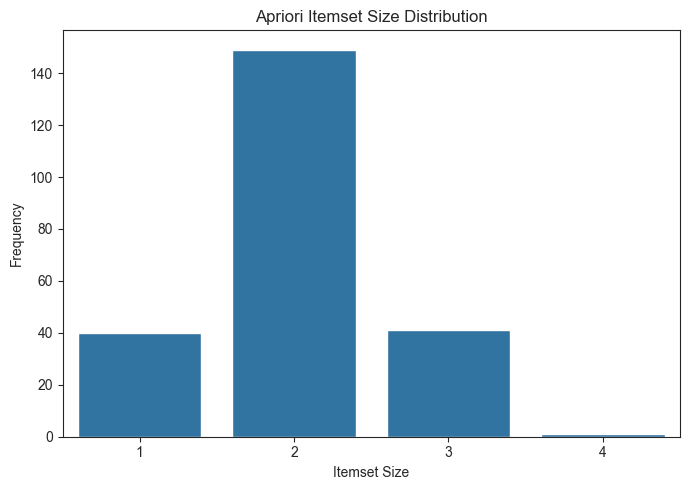

In [26]:
size_counts = (
    apriori_itemsets["itemset_size"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=size_counts.index,
    y=size_counts.values
)

plt.title("Apriori Itemset Size Distribution")
plt.xlabel("Itemset Size")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Apriori Association Rules

Association rules are created from the discovered frequent itemsets. Only rules with confidence greater than or equal to 0.50 and lift greater than one are retained for interpretation.

In [27]:
apriori_rules = association_rules(
    apriori_itemsets,
    metric="confidence",
    min_threshold=0.50
)

apriori_rules = apriori_rules[
    apriori_rules["lift"] > 1
]

print("Rules Generated:", len(apriori_rules))

Rules Generated: 126


In [28]:
apriori_rules["Antecedent"] = (
    apriori_rules["antecedents"]
    .apply(lambda x:", ".join(sorted(x)))
)

apriori_rules["Consequent"] = (
    apriori_rules["consequents"]
    .apply(lambda x:", ".join(sorted(x)))
)

rule_table = (
    apriori_rules[
        [
            "Antecedent",
            "Consequent",
            "support",
            "confidence",
            "lift"
        ]
    ]
    .sort_values(
        by="lift",
        ascending=False
    )
)

rule_table.head(15)

,Antecedent,Consequent,support,confidence,lift
17,"REGENCY CAKESTAND 3 TIER, ROSES REGENCY TEACUP...",GREEN REGENCY TEACUP AND SAUCER,0.030102,0.790749,10.118532
125,"JUMBO BAG PINK POLKADOT, JUMBO SHOPPER VINTAGE...","JUMBO BAG RED RETROSPOT, JUMBO STORAGE BAG SUKI",0.022137,0.581498,9.935448
16,"GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKES...",ROSES REGENCY TEACUP AND SAUCER,0.030102,0.790749,9.864510
123,"JUMBO BAG PINK POLKADOT, JUMBO STORAGE BAG SUKI","JUMBO BAG RED RETROSPOT, JUMBO SHOPPER VINTAGE...",0.022137,0.522772,9.489471
3,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.058695,0.732218,9.369557
2,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.058695,0.751073,9.369557
1,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.047208,0.605376,8.241688
0,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.047208,0.642694,8.241688
124,"JUMBO SHOPPER VINTAGE RED PAISLEY, JUMBO STORA...","JUMBO BAG PINK POLKADOT, JUMBO BAG RED RETROSPOT",0.022137,0.514620,7.818289
45,"LUNCH BAG BLACK SKULL., LUNCH BAG APPLE DESIGN",LUNCH BAG SUKI DESIGN,0.021801,0.654912,7.649832


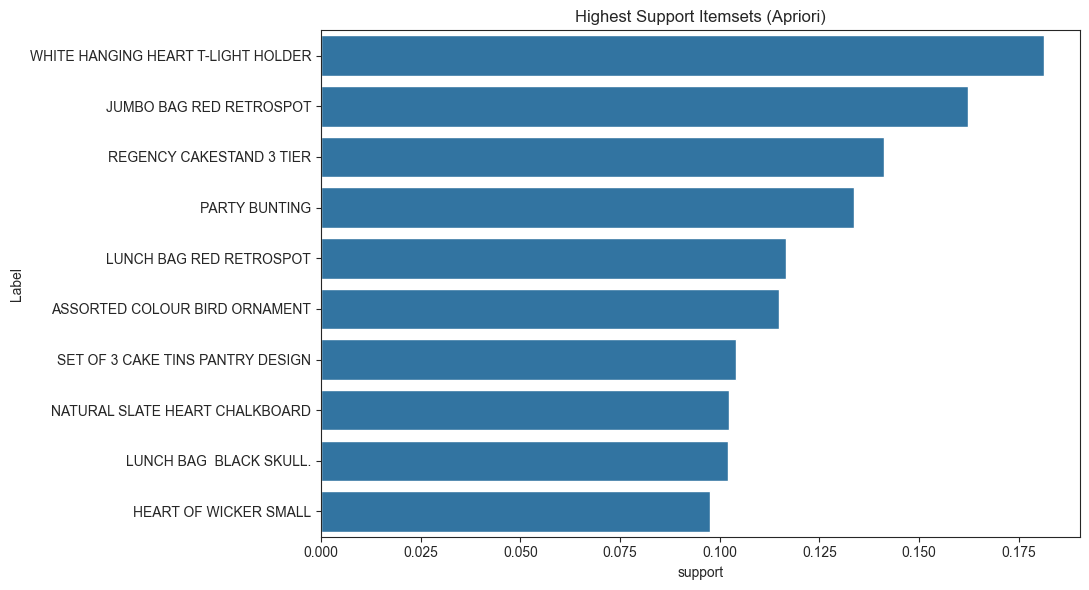

In [29]:
top_support = (
    apriori_itemsets
    .sort_values(
        "support",
        ascending=False
    )
    .head(10)
    .copy()
)

top_support["Label"] = (
    top_support["itemsets"]
    .apply(lambda x:", ".join(sorted(x)))
)

plt.figure(figsize=(11,6))

sns.barplot(
    data=top_support,
    x="support",
    y="Label"
)

plt.title("Highest Support Itemsets (Apriori)")

plt.tight_layout()

plt.show()

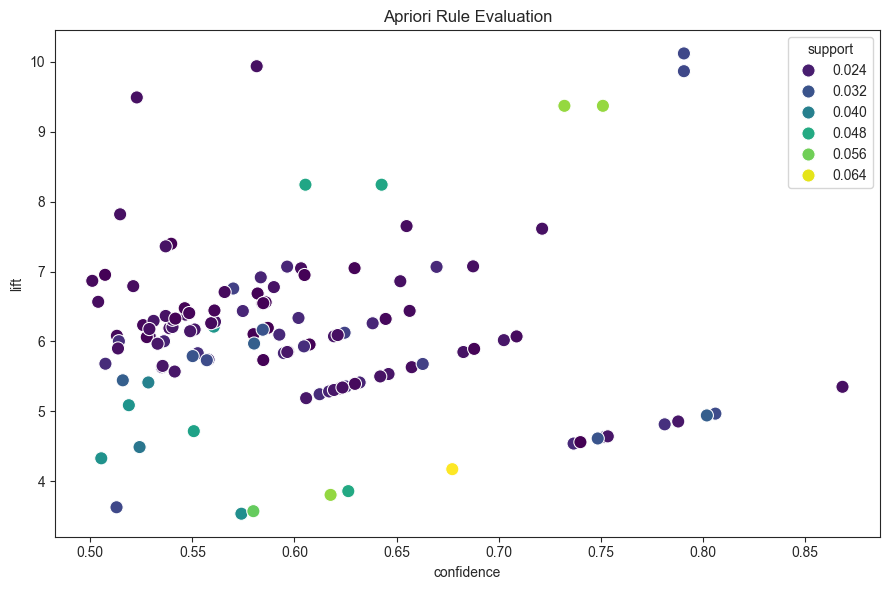

In [30]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=apriori_rules,
    x="confidence",
    y="lift",
    hue="support",
    palette="viridis",
    s=90
)

plt.title("Apriori Rule Evaluation")

plt.tight_layout()

plt.show()

# Rule Interpretation

Rules appearing in the upper-right region of the scatter plot demonstrate both strong confidence and high lift. Such rules are useful for identifying products that customers frequently purchase together and may support recommendation systems or bundled promotions.

In [31]:
comparison = pd.DataFrame({
    "Algorithm":[
        "FP-Growth",
        "Apriori"
    ],
    "Frequent Itemsets":[
        len(fp_itemsets),
        len(apriori_itemsets)
    ],
    "Association Rules":[
        len(fp_rules),
        len(apriori_rules)
    ],
    "Execution Time":[
        fp_runtime,
        apriori_runtime
    ]
})

comparison

,Algorithm,Frequent Itemsets,Association Rules,Execution Time
0,FP-Growth,231,126,1.402362
1,Apriori,231,126,0.249001


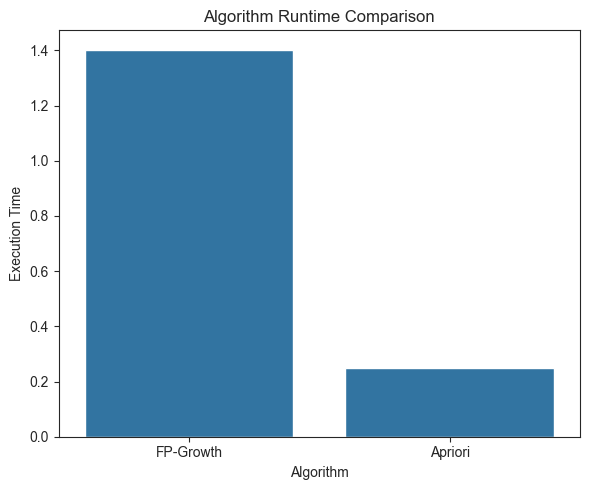

In [32]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Execution Time"
)

plt.title("Algorithm Runtime Comparison")

plt.tight_layout()

plt.show()

# Algorithm Comparison

Both algorithms identified frequent purchasing patterns using the same transaction data and minimum support threshold. The runtime comparison illustrates their computational performance, while the itemset and rule counts demonstrate the effectiveness of each approach for market basket analysis.

In [33]:
comparison.describe(include="all")

,Algorithm,Frequent Itemsets,Association Rules,Execution Time
count,2,2.0,2.0,2.000000
unique,2,NaN,NaN,NaN
top,FP-Growth,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,231.0,126.0,0.825682
std,NaN,0.0,0.0,0.815549
min,NaN,231.0,126.0,0.249001
25%,NaN,231.0,126.0,0.537341
50%,NaN,231.0,126.0,0.825682
75%,NaN,231.0,126.0,1.114022


# Final Findings

This analysis used the Online Retail dataset to study product purchasing relationships through FP-Growth and Apriori.

The main findings are:

- Frequently purchased products produced the strongest individual support values.
- Several product pairs and larger combinations appeared repeatedly across invoices.
- FP-Growth and Apriori produced comparable frequent itemsets when the same support threshold was applied.
- Confidence identified how reliably one product predicted another product.
- Lift helped distinguish meaningful relationships from combinations that occurred only because both products were individually popular.
- Rules with high confidence, lift, and reasonable support were the most valuable for interpretation.

# Practical Business Applications

The discovered association rules can support retail decision-making in several ways:

1. **Product Recommendations**  
   Items connected by strong association rules can be recommended together during online shopping.

2. **Bundle Promotions**  
   Frequently purchased product combinations can be offered as discounted bundles.

3. **Cross-Selling**  
   A retailer can suggest the consequent product when a customer selects the antecedent product.

4. **Inventory Planning**  
   Products that frequently occur together may require coordinated inventory management.

5. **Store and Website Organization**  
   Related products can be placed near each other in physical stores or online product pages.

6. **Targeted Marketing**  
   Customer promotions can be developed around commonly associated product groups.

# Challenges and Limitations

Several challenges were considered during the analysis:

- The original dataset contained missing descriptions, cancelled invoices, returns, and invalid prices.
- Thousands of unique products created a large and sparse transaction matrix.
- Limiting the analysis to the most frequent products improved performance but excluded less common items.
- The selected support and confidence thresholds influenced the number of discovered patterns.
- High lift alone does not guarantee business importance because some high-lift rules may have low support.
- Runtime results depend on the computer, package versions, and notebook environment.
- The analysis focuses on product co-occurrence and does not include customer demographics or seasonal behavior.

Future analysis could examine different countries, customer groups, time periods, or support thresholds.

# Conclusion

The lab successfully demonstrated frequent pattern mining and association rule generation using FP-Growth and Apriori.

The retail data was cleaned, standardized, and transformed into a Boolean transaction basket. FP-Growth was applied first to discover frequently occurring product combinations, followed by Apriori using the same minimum support threshold. Association rules were then evaluated through support, confidence, and lift.

Both algorithms were effective for finding recurring purchasing patterns. FP-Growth avoids repeated candidate generation, while Apriori provides a direct candidate-based approach that is easy to understand. The runtime comparison showed how their computational behavior differed in the current execution environment.

Overall, association rule mining provided useful insights that could support recommendations, cross-selling, product bundling, inventory planning, and targeted promotions.

# References

Han, J., Kamber, M., & Pei, J. (2012). *Data mining: Concepts and techniques* (3rd ed.). Morgan Kaufmann.

Raschka, S. (2018). MLxtend: Providing machine learning and data science utilities and extensions to Python's scientific computing stack. *Journal of Open Source Software, 3*(24), 638.

UCI Machine Learning Repository. (n.d.). *Online Retail Data Set*. University of California, Irvine.

Waskom, M. L. (2021). Seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021.